critical_stretch:  0.0004618802153517005
allow_damage in main: True
thickness inputted:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


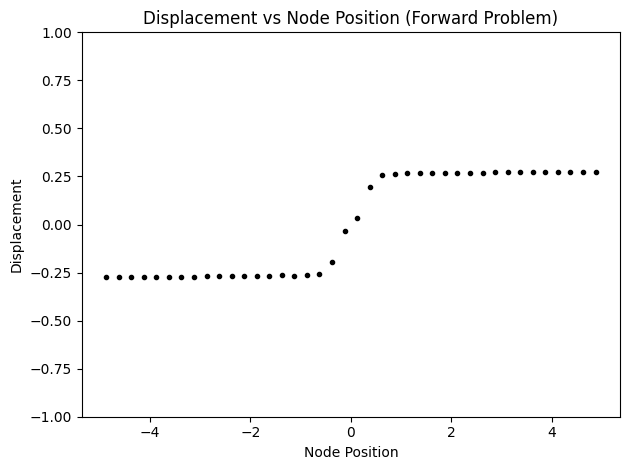

thickness:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [2]:
from functools import partial
import time

import jax
import jax.numpy as jnp

import numpy as np
import scipy.spatial
import scipy.optimize
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation



import jax.scipy
import jax.scipy.optimize
from jax.scipy.optimize import minimize
from jax.nn import softplus

from jax import grad, jit


from typing import Union, Tuple

import optax
from jax import jit, vmap, grad, value_and_grad
from jax import lax
from jax import grad
from jax.experimental import checkify


import jax
import jax.numpy as jnp
import numpy as np
import scipy.spatial
from typing import Union, NamedTuple, Optional


# ----------------------------
# PARAMETER STRUCT
# ----------------------------
class PDParams(NamedTuple):
	bar_length: float
	number_of_elements: int
	bulk_modulus: float
	density: float
	thickness: jnp.ndarray
	horizon: float
	critical_stretch: Optional[float]
	prescribed_velocity: Optional[float]
	prescribed_force: Optional[float]
	nodes: jnp.ndarray
	lengths: jnp.ndarray
	pd_nodes: jnp.ndarray
	num_nodes: int
	neighborhood: jnp.ndarray
	reference_position_state: jnp.ndarray
	reference_magnitude_state: jnp.ndarray
	num_neighbors: jnp.ndarray
	max_neighbors: int
	no_damage_region_left: jnp.ndarray
	no_damage_region_right: jnp.ndarray
	width: float  
	right_bc_region: jnp.ndarray
	left_bc_region: jnp.ndarray
	undamaged_influence_state_left: jnp.ndarray
	undamaged_influence_state_right: jnp.ndarray


class PDState(NamedTuple):
	disp: jnp.ndarray
	vel: jnp.ndarray
	acc: jnp.ndarray
	vol_state: jnp.ndarray
	rev_vol_state: jnp.ndarray
	influence_state: jnp.ndarray
	undamaged_influence_state: jnp.ndarray
	damage: jnp.ndarray
	forces_array: jnp.ndarray
	disp_array: jnp.ndarray
	velo_array: jnp.ndarray
	strain_energy: float
	time: float


# ----------------------------
# GLOBAL INITIALIZATION FUNCTION
# ----------------------------
def init_problem(bar_length: float = 20.0,
				 density: float = 1.0,
				 bulk_modulus: float = 100.0,
				 number_of_elements: int = 20,
				 horizon: Optional[float] = None,
				 thickness: Union[float, np.ndarray] = 1.0,
				 prescribed_velocity: Optional[float] = None,
				 prescribed_force: Optional[float] = None,
				 critical_stretch: Optional[float]= None):

	
	"""
	Create PDParams and PDState tuples for a new problem.
	"""

	delta_x = bar_length / number_of_elements
	if horizon is None:
		horizon = delta_x * 3.015

	# thickness as array
	if isinstance(thickness, float) or np.isscalar(thickness):
		thickness_arr = jnp.ones(number_of_elements) * thickness
	elif isinstance(thickness, (np.ndarray, jnp.ndarray)):
		thickness_arr = jnp.asarray(thickness)
		assert thickness_arr.shape[0] == number_of_elements, ValueError("Thickness array length must match number of elements")
	else:
		raise ValueError("thickness must be a float or array")
	
	# nodes and element lengths
	nodes = jnp.linspace(-bar_length / 2.0, bar_length / 2.0, num=number_of_elements + 1)
	lengths = jnp.array(nodes[1:] - nodes[0:-1])
	pd_nodes = jnp.array(nodes[0:-1] + lengths / 2.0)
	num_nodes = pd_nodes.shape[0]

	# kdtree setup
	tree = scipy.spatial.cKDTree(pd_nodes[:, None])
	reference_magnitude_state, neighborhood = tree.query(
		pd_nodes[:, None], k=100, p=2, eps=0.0,
		distance_upper_bound=(horizon + np.max(lengths) / 2.0))

	# trim out self-distance column
	reference_magnitude_state = jnp.delete(reference_magnitude_state, 0, 1)

	num_neighbors = jnp.asarray((neighborhood != tree.n).sum(axis=1)) - 1
	max_neighbors = int(np.max((neighborhood != tree.n).sum(axis=1)))

	neighborhood = jnp.asarray(neighborhood[:, :max_neighbors])
	reference_magnitude_state = reference_magnitude_state[0:, :max_neighbors - 1]

	row_indices = jnp.arange(neighborhood.shape[0]).reshape(-1, 1)
	neighborhood = jnp.where(neighborhood == tree.n, row_indices, neighborhood)
	neighborhood = jnp.delete(neighborhood, 0, 1)

	reference_position_state = pd_nodes[neighborhood] - pd_nodes[:, None]
	reference_magnitude_state = jnp.where(reference_magnitude_state == np.inf, 0.0, reference_magnitude_state)
	#jax.debug.print("reference_magnitude_state = {r}", r=reference_magnitude_state)

	if prescribed_velocity is not None and prescribed_force is not None:
		raise ValueError("Only one of prescribed_velocity or prescribed_force should be set, not both.")
	
	if prescribed_velocity is None and prescribed_force is None:
		raise ValueError("Either prescribed_velocity or prescribed_force must be set.")

	#:The node indices of the boundary region at the left end of the bar
	li = 0
	left_bc_mask = neighborhood[li] != li
	left_bc_region = neighborhood[li][left_bc_mask]

	#:The node indices of the boundary region at the right end of the bar
	ri = num_nodes - 1
	right_bc_mask = neighborhood[ri] != ri
	right_bc_region = neighborhood[ri][right_bc_mask]

	#left_bc_region = jnp.asarray(tree.query_ball_point(pd_nodes[0, None], r=(2.0 * horizon ), p=2, eps=0.0)).sort()

	#right_bc_region = jnp.asarray(tree.query_ball_point(pd_nodes[-1, None], r=(2.0 * horizon ), p=2, eps=0.0)).sort()


	if prescribed_velocity is not None:
		left_bc_region = jnp.asarray(tree.query_ball_point(pd_nodes[0, None], r=(horizon + np.max(lengths) / 2.0), p=2, eps=0.0)).sort()
		right_bc_region = jnp.asarray(tree.query_ball_point(pd_nodes[-1, None], r=(horizon + np.max(lengths) / 2.0), p=2, eps=0.0)).sort()

	# no-damage regions
    # set to 4.0 for previous results, but for scalar bar trying 2.0
	no_damage_region_left = jnp.asarray(
		tree.query_ball_point(pd_nodes[0, None], r=(4.0 * horizon + np.max(lengths) / 2.0), p=2, eps=0.0)
	).sort()
	no_damage_region_right = jnp.asarray(
		tree.query_ball_point(pd_nodes[-1, None], r=(4.0 * horizon + np.max(lengths) / 2.0), p=2, eps=0.0)
	).sort()


	# initial vol_state (full volume)
	vol_state = jnp.ones((num_nodes, max_neighbors - 1))
	rev_vol_state = vol_state.copy()

	#jax.debug.print("vol_state in init: {v}",v=vol_state)

	influence_state = jnp.where(vol_state > 1.0e-16, 1.0, 0.0)
	undamaged_influence_state = influence_state.copy()
	
	undamaged_influence_state_left = influence_state.at[no_damage_region_left, :].get()
	undamaged_influence_state_right = influence_state.at[no_damage_region_right, :].get()

	width = 1.0  # Width of the bar, can be adjusted if needed


	# package params
	params = PDParams(
		bar_length, number_of_elements, bulk_modulus, density, thickness_arr,
		horizon, critical_stretch, prescribed_velocity, prescribed_force,
		nodes, lengths, pd_nodes, num_nodes, neighborhood,
		reference_position_state, reference_magnitude_state, num_neighbors, max_neighbors,
		no_damage_region_left, no_damage_region_right, width, right_bc_region, left_bc_region,
		undamaged_influence_state_left, undamaged_influence_state_right
	)


	# package initial state
	state = PDState(
		disp=jnp.zeros(num_nodes),
		vel=jnp.zeros(num_nodes),
		acc=jnp.zeros(num_nodes),
		vol_state=vol_state,
		rev_vol_state=rev_vol_state,
		influence_state=influence_state,
		undamaged_influence_state=undamaged_influence_state,
		forces_array=jnp.zeros(num_nodes),
		disp_array=jnp.zeros(num_nodes),
		velo_array=jnp.zeros(num_nodes),
		strain_energy=0.0,
		damage=jnp.zeros(num_nodes),
		time=0.0
	)

	return params, state


############### global functions to replace jnp.where functions in compute_partial_volumes ###############
@jax.jit
def vol_state_uncorrected_where(ref_mag_state: jax.Array, vol_state_uncorrected: jax.Array):
	"""
	Replace entries in vol_state_uncorrected with 0.0 where ref_mag_state < 1.0e-16,
	using lax.cond and nested vmap for full JIT/grad compatibility.
	Works for 1D or 2D arrays.
	"""
	# Scalar conditional
	def cond_fn(r, v):
		return jax.lax.cond(r < 1e-16, lambda _: 0.0, lambda _: v, operand=None)

	# Vectorize over columns (neighbors)
	col_fn = jax.vmap(cond_fn, in_axes=(0, 0))
	# Vectorize over rows (nodes)
	return jax.vmap(col_fn, in_axes=(0, 0))(ref_mag_state, vol_state_uncorrected)


@jax.jit
def vol_state_where(ref_mag_state: jax.Array, horiz: float, lens: jax.Array, neigh: jax.Array, vol_state_uncorrected: jax.Array):
	"""
	Replace entries in vol_state_uncorrected with 0.0 where
	ref_mag_state >= horiz + lens[neigh] / 2.0,
	using lax.cond and nested vmap.
	Works for 1D or 2D arrays.
	"""
	threshold = horiz + lens[neigh] / 2.0  # shape matches ref_mag_state

	# Scalar conditional
	def cond_fn(r, thresh, v):
		return jax.lax.cond(r < thresh, lambda _: v, lambda _: 0.0, operand=None)

	# Vectorize over columns (neighbors)
	col_fn = jax.vmap(cond_fn, in_axes=(0, 0, 0))
	# Vectorize over rows (nodes)
	return jax.vmap(col_fn, in_axes=(0, 0, 0))(ref_mag_state, threshold, vol_state_uncorrected)


def vol_state_clip_where(vol_state: jax.Array, vol_state_uncorrected: jax.Array):
    return jnp.minimum(vol_state, vol_state_uncorrected)

######################################################################################
def compute_partial_volumes(params, thickness:jax.Array):

	# Setup some local (to function) convenience variables
	neigh = params.neighborhood
	lens = params.lengths
	ref_mag_state = params.reference_magnitude_state
	horiz = params.horizon


	# Initialize the volume_state to the lengths * width * thickness
	width = params.width
	vol_state_uncorrected = lens[neigh] * thickness[neigh] * width 

	#Zero out entries that are not in the family
	#vol_state_uncorrected = jnp.where(ref_mag_state < 1.0e-16, 0.0, vol_state_uncorrected) 
	vol_state_uncorrected = vol_state_uncorrected_where(ref_mag_state, vol_state_uncorrected)


	#vol_state = jnp.where(ref_mag_state < horiz + lens[neigh] / 2.0, vol_state_uncorrected, 0.0)
	vol_state = vol_state_where(ref_mag_state, horiz, lens, neigh, vol_state_uncorrected)  

	# Check to see if the neighboring node has a partial volume
	is_partial_volume = jnp.abs(horiz - ref_mag_state) < lens[neigh] / 2.0
	#jax.debug.print("Any NaNs? {y}", y=jnp.any(jnp.isnan(is_partial_volume)))

	# Two different scenarios:
	is_partial_volume_case1 = is_partial_volume * (ref_mag_state >= horiz)
	is_partial_volume_case2 = is_partial_volume * (ref_mag_state < horiz)

	# Compute the partial volumes conditionally
	vol_state = jnp.where(is_partial_volume_case1, (lens[neigh] / 2.0 - (ref_mag_state - horiz)) * width * thickness[neigh], vol_state)
	vol_state = jnp.where(is_partial_volume_case2, (lens[neigh] / 2.0 + (horiz - ref_mag_state)) * width * thickness[neigh], vol_state)


	# If the partial volume is predicted to be larger than the unocrrected volume, set it back
	#vol_state = jnp.where(vol_state > vol_state_uncorrected, vol_state_uncorrected, vol_state)
	vol_state = vol_state_clip_where(vol_state, vol_state_uncorrected)
	EPS_vol = 1e-6
	vol_state = jnp.maximum(vol_state, EPS_vol)


	# Now compute the "reverse volume state", this is the partial volume of the "source" node, i.e. node i,
	# as seen from node j.  This doesn't show up anywhere in any papers, it's just used here for computational
	# convenience
	vol_array = lens[:,None] * width * thickness[:, None]
	#jax.debug.print("Any NaNs? {y}", y=jnp.any(jnp.isnan(vol_array)))

	rev_vol_state = jnp.ones_like(vol_state) * vol_array
	#jax.debug.print("Any NaNs? {y}", y=jnp.any(jnp.isnan(rev_vol_state)))
	
	rev_vol_state = jnp.where(is_partial_volume_case1, (lens[:, None] / 2.0 - (ref_mag_state - horiz)) * width * thickness[:, None], rev_vol_state)
	rev_vol_state = jnp.where(is_partial_volume_case2, (lens[:, None] / 2.0 + (horiz - ref_mag_state)) * width * thickness[:, None], rev_vol_state)



	#If the partial volume is predicted to be larger than the uncorrected volume, set it back
	#rev_vol_state = jnp.where(rev_vol_state > vol_array, vol_array, rev_vol_state)
	rev_vol_state = vol_state_clip_where(rev_vol_state, vol_array)
	rev_vol_state = jnp.maximum(rev_vol_state, EPS_vol)

	return (vol_state, rev_vol_state)

'''
@jax.jit
def my_where(x: jax.Array):
	# Elementwise comparison without jnp.where, using list comprehension
	return jnp.array([i if i >= 1E-12 else 1E-12 for i in x])
'''

###### functions to replace jnp.where with lax.cond for vectorized operations ######
@jax.jit
def my_where(x: jax.Array):
	def scalar_where(i):
		return jax.lax.cond(i >= 1e-12, lambda _: i, lambda _: 1e-12, operand=None)
	return jax.vmap(scalar_where)(x)

@jax.jit
def my_stretch_where(ref_mag_state, exten_state):
    # r, e both shape (num_nodes, num_neighbors)
	
    return jnp.where(ref_mag_state > 1e-16, exten_state / ref_mag_state, 0.0)


@jax.jit
def inf_state_where(inf_state: jax.Array, stretch: jax.Array, critical_stretch: float):
	"""
	Zero out inf_state where stretch > critical_stretch, using lax.cond and double vmap.
	Works for 2D arrays (nodes x neighbors) or 1D arrays.
	"""
	# Scalar conditional
	def cond_fn(s, i):
		return jax.lax.cond(s > critical_stretch, lambda _: 0.0, lambda _: i, operand=None)

	# Vectorize over columns (neighbors)
	row_fn = jax.vmap(cond_fn, in_axes=(0, 0))
	# Vectorize over rows (nodes)
	return jax.vmap(row_fn, in_axes=(0, 0))(stretch, inf_state)

@jax.jit
def my_replace_zero_val_where(x_array: jax.Array, eps: float):
	"""
	Replace zeros in x_array with eps, using lax.cond and double vmap.
	Works for 1D or 2D arrays.
	"""
	# Scalar conditional
	def cond_fn(i):
		return jax.lax.cond(i == 0.0, lambda _: eps, lambda _: i, operand=None)

	# Vectorize over columns
	row_fn = jax.vmap(cond_fn, in_axes=0)
	# Vectorize over rows
	return jax.vmap(row_fn, in_axes=0)(x_array)

@jax.jit
def shape_tens_eps_where(shape_tens: jax.Array, epsilon: float):
	def cond_fn(val):
		return jax.lax.cond(jnp.abs(val) < epsilon, lambda _: epsilon, lambda _: val, operand=None)
	return jax.vmap(cond_fn)(shape_tens)

	
### to wrap jnp.where to try to get rid of nans in grad
@jax.jit
def safe_divide(num: jax.Array, denom: jax.Array, eps: float = 1e-12):
	"""
	Safely divide num / denom, replacing small denom values with 1.0
	using lax.cond and double vmap for vectorized arrays.
	"""

	# Scalar conditional
	def cond_fn(d):
		return jax.lax.cond(jnp.abs(d) < eps, lambda _: 1.0, lambda _: d, operand=None)

	# Vectorize over columns
	row_fn = jax.vmap(cond_fn, in_axes=0)
	# Vectorize over rows
	denom_safe = jax.vmap(row_fn, in_axes=0)(denom)

	return num / denom_safe
###########################

# Compute the force vector-state using a LPS peridynamic formulation
@partial(jit, static_argnums=(4,))
def compute_force_state_LPS(params,disp:jax.Array,  vol_state:jax.Array, inf_state:jax.Array, allow_damage: bool) -> Tuple[jax.Array, jax.Array]:
		
	#Define some local convenience variables     
	ref_pos = params.pd_nodes 
	ref_pos_state = params.reference_position_state
	ref_mag_state = params.reference_magnitude_state
	neigh = params.neighborhood
	K = params.bulk_modulus
	critical_stretch = params.critical_stretch
	no_damage_region_left = params.no_damage_region_left
	no_damage_region_right = params.no_damage_region_right
	undamaged_influence_state_left = params.undamaged_influence_state_left
	undamaged_influence_state_right = params.undamaged_influence_state_right
 

	#disp = 0.001
	#disp =  disp[0]
	#jnp.zeros_like(ref_pos)
	#jax.debug.print("critical_stretch = {c}", c=critical_stretch)

	#Compute the deformed positions of the nodes
	def_pos = ref_pos + disp
	#jax.debug.print("disp: {d}", d=disp)

	#Compute deformation state
	def_state = def_pos[neigh] - def_pos[:,None]
	#jax.debug.print("def_state finite: {b}", b=jnp.all(jnp.isfinite(def_state)))
	#jax.debug.print("def_state zeros? {z}", z=jnp.any(def_state == 0))

	
	# Compute deformation magnitude state
	#def_mag_state = jnp.sqrt(def_state * def_state)
	#def_mag_state = jnp.linalg.norm(def_state, axis=-1)
	#def_mag_state = (def_state * def_state) ** 0.5
	def_mag_state = jnp.sqrt(jnp.maximum(def_state * def_state, 1e-24))
	#jax.debug.print("def_mag_state: {b}", b=def_mag_state)


	# Compute deformation unit state
	eps = 1e-10
	def_unit_state = def_state / (def_mag_state + 1e-12)
	#def_unit_state = jnp.where(def_mag_state > 1.0e-12, def_state / def_mag_state, 0.0)
	#def_unit_state = my_stretch_where(def_mag_state[..., None], def_state)
	def_unit_state = jnp.where(def_mag_state > eps,
							def_state / def_mag_state, 0.0)
	#def_unit_state = jax.vmap(safe_unit)(def_state, def_mag_state)


	# Compute scalar extension state
	exten_state = def_mag_state - ref_mag_state
 	#exten_state = def_mag_state[:, None] - ref_mag_state

	#exten_state = def_mag_state - ref_mag_state
	#jax.debug.print("[exten_state] min={m} max={M}",  m=jnp.min(exten_state), M=jnp.max(exten_state))

	## switched out for jnp where OG code to see if 
	stretch = jnp.where(ref_mag_state > 1.0e-16, exten_state / ref_mag_state, 0.0)
	#jax.debug.print("stretch beofore my_stretch_where {s}", s=exten_state / ref_mag_state)
	#stretch = my_stretch_where(ref_mag_state, exten_state)

    # Apply critical stretch fracture criteria to update inf state
	def damage_branch(inf_state):
		#inf_state_updated = jnp.where(stretch > critical_stretch, 0.0, inf_state)
		#inf_state = inf_state_where(inf_state, stretch, critical_stretch)
		inf_state = jnp.where(stretch > critical_stretch, 0.0, inf_state)
		#jax.debug.print("inf_state after inf_state_where {i}", i=inf_state)
		inf_state = inf_state.at[no_damage_region_left, :].set(undamaged_influence_state_left)
		inf_state = inf_state.at[no_damage_region_right, :].set(undamaged_influence_state_right)
		return inf_state

	def no_damage_branch(inf_state):
		# return state unchanged
		return inf_state


  
	# Apply a critical strech fracture criteria
	inf_state_updated = lax.cond(allow_damage, damage_branch, no_damage_branch, inf_state)
	#jax.debug.print("inf_state after damage/no_damage_branch {i}", i=inf_state)

	#jax.debug.print("[inf_state pre-eps] any==0? {z} finite={f}",
				#z=jnp.any(inf_state == 0.0), f=jnp.all(jnp.isfinite(inf_state)))

	eps = 1e-10  # or smaller if your scale is tiny

	#inf_state = jnp.where(inf_state == 0.0, eps, inf_state)
	inf_state = my_replace_zero_val_where(inf_state, eps)

	#ref_pos_state = jnp.where(ref_pos_state == 0.0, eps, ref_pos_state)
	ref_pos_state = my_replace_zero_val_where(ref_pos_state, eps) 
	#jax.debug.print("ref_pos_state zeros? {z}", z=jnp.any(ref_pos_state == 0))
	
	# Compute the shape tensor (really a scalar because this is 1d), i.e. the "weighted volume" as 
	# defined in Silling et al. 2007
	# added epsilon to prevent dividing by zero
	epsilon = 1e-8
	shape_tens = (inf_state * ref_pos_state * ref_pos_state * vol_state).sum(axis=1)
	#shape_tens = jnp.where(jnp.abs(shape_tens) < epsilon, epsilon, shape_tens)
	#shape_tens = shape_tens_eps_where(shape_tens, epsilon)
	shape_tens = jnp.maximum(shape_tens, epsilon)
	

	# Compute scalar force state for a elastic constitutive model
	######### compute strain energy density here?  or calculation at least should look like this line here ########
	#scalar_force_state = 9.0 * K / shape_tens[:, None] * exten_state
	scalar_force_state = 9.0 * K * safe_divide(exten_state, shape_tens[:, None])

	# bond strain energy calc
	#bond_strain_energy = 9.0 * K / shape_tens[:, None] * exten_state * exten_state * ref_mag_state
	bond_strain_energy = 9.0 * K * safe_divide(exten_state**2 * ref_mag_state, shape_tens[:, None])

	# Compute the force state
	force_state = inf_state * scalar_force_state * def_unit_state
	#jax.debug.print("force_state finite: {b}", b=force_state)

	###  return bond_strain_energy
	return force_state, inf_state_updated, bond_strain_energy



def smooth_ramp(t, t0, c=1.0, beta=5.0):
	"""
	Function that linearly ramps up to c at t0, then smoothly transitions to c.

	Parameters:
	- t: Time variable (scalar or numpy array).
	- t0: Time at which the transition occurs.
	- c: Final constant value after transition.
	- beta: Smoothness parameter (higher values = sharper transition).

	Returns:
	- f: Value of the function at time t.
	"""
	# Linear ramp before t0 (with slope c/t0)
	linear_ramp = (c / t0) * t

	# Smooth transition using an exponential decay term
	smooth_transition = c * (1 - jnp.exp(-beta * (t - t0))) + (c / t0) * t0

	# Use `jnp.where` to define the piecewise function
	f = jnp.where(t < t0, linear_ramp, smooth_transition)
 
	
	return f

@jax.jit
def save_if_needed(forces_array, force_value, step_number):
    """
    Save force_value into forces_array based on step_number rules:
      - every step when step_number < 100
      - every 500 steps when 100 <= step_number < 2000
      - every 5000 steps when step_number >= 2000
    """
    mask = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_number <= 6000, step_number % 500 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                step_number % 1000 == 0
            )
        )
    )

    
    '''
    mask = jnp.logical_or(
        jnp.logical_or(
            # Phase 1: 0-6000, every 500 steps
            jnp.logical_and(step_number <= 6000, step_number % 500 == 0),

            # Phase 2: 6000-12000, every 1000 steps
            jnp.logical_and(
                step_number > 6000,
                jnp.logical_and(
                    step_number <= 13000,
                    step_number % 1000 == 0
                )
            )
        ),
        
        # Phase 3: 13000-43000, every 5000 steps
        jnp.logical_and(
            step_number > 13000,
            jnp.logical_and(
                step_number <= 43000,
                step_number % 5000 == 0
            )
        )
    )
    '''

    # Use lax.cond to choose branch without Python-side branching
    def write(arr):
        return arr.at[step_number].set(force_value)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, forces_array)

@jax.jit
def calc_damage_if_needed(vol_state, inf_state, undamaged_inf_state, damage, step_number, force_value):
    """
    If step_number is one we want to save, write force_value at that index,
    otherwise return forces_array unchanged.
    """

    mask = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_number <= 6000, step_number % 500 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                step_number % 1000 == 0
            )
        )
    )

	
    # Use lax.cond to choose branch without Python-side branching
    
    def write(arr):
        damage = compute_damage(vol_state, inf_state, undamaged_inf_state)
        return arr.at[step_number].set(damage)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, damage)

@jax.jit
def save_disp_if_needed(disp_array, disp_value, step_number):
    """
    If step_number is one we want to save, write disp_value at that index,
    otherwise return disp_array unchanged.
    """
    mask = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_number <= 6000, step_number % 500 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                step_number % 1000 == 0
            )
        )
    )

    # Use lax.cond to choose branch without Python-side branching
    def write(arr):
        return arr.at[step_number].set(disp_value)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, disp_array)

@jax.jit
def save_velo_if_needed(velo_array, velo_value, step_number):
    """
    If step_number is one we want to save, write velo_value at that index,
    otherwise return velo_array unchanged.
    """
    mask = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_number <= 6000, step_number % 500 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_number >= 6000,
            jnp.logical_and(
                step_number <= 15000,
                step_number % 1000 == 0
            )
        )
    )

    # Use lax.cond to choose branch without Python-side branching
    def write(arr):
        return arr.at[step_number].set(velo_value)
    def skip(arr):
        return arr
    return jax.lax.cond(mask, write, skip, velo_array)

# Internal force calculation
#@jax.jit(static_argnums=7)  
@partial(jax.jit, static_argnums=(14))
def compute_internal_force(params, disp, vol_state, rev_vol_state, inf_state, undamaged_inf_state, damage, thickness, time, time_step, num_steps, forces_array, disp_array, step_number, allow_damage):

	# Define some local convenience variables     
	neigh = params.neighborhood
	prescribed_force = params.prescribed_force
	width = params.width
	num_nodes = params.num_nodes
	left_bc_region = params.left_bc_region
	right_bc_region = params.right_bc_region

	#jax.debug.print("disp zeros? {z}", z=jnp.any(disp == 0))
	

	##### return bond_strain_energy #####
	force_state, inf_state, bond_strain_energy = compute_force_state_LPS(params, disp, vol_state, inf_state, allow_damage)

	#Integrate nodal forces 
	force = (force_state * vol_state).sum(axis=1)
	force = force.at[neigh].add(-force_state * rev_vol_state)

	#strain_energy = bond_strain_energy
	strain_energy = 0.5 * (bond_strain_energy * vol_state).sum(axis=1)

	#total_strain_energy = jnp.sum(strain_energy)
	#jax.debug.print("strain_energy: {s}", s=jnp.sum(strain_energy))

	if prescribed_force is not None:
		li = 0
		ri = num_nodes - 1
		#ramp_force = smooth_ramp(time, t0=1.e-3, c=prescribed_force) 
		ramp_force = smooth_ramp(time, t0=1.e-5, c=prescribed_force) 



		denom_left  = vol_state[li].sum() + rev_vol_state[li][0]
		denom_right = vol_state[ri].sum() + rev_vol_state[ri][0]



		eps = 1e-12
		#denom_left  = jnp.where(jnp.abs(denom_left)  < eps, eps, denom_left)
		#denom_right = jnp.where(jnp.abs(denom_right) < eps, eps, denom_right)

		denom_left  = jnp.clip(denom_left,  1e-3, jnp.inf)
		denom_right = jnp.clip(denom_right, 1e-3, jnp.inf)


		# Compute the left boundary condition nodal forces
		left_bc_area = width * thickness[left_bc_region]
		#left_bc_nodal_forces = (ramp_force * left_bc_area)/(vol_state[li].sum() + rev_vol_state[li][0])
		left_bc_nodal_forces = (ramp_force * left_bc_area)/denom_left
		force = force.at[left_bc_region].add(-left_bc_nodal_forces)

		# For the leftmost node (if needed)
		left_bc_area_li = width * thickness[li]
		force = force.at[li].add(-ramp_force * left_bc_area_li)

		# Compute the right boundary condition nodal forces
		right_bc_area = width * thickness[right_bc_region]
		#right_bc_nodal_forces = (ramp_force * right_bc_area)/(vol_state[ri].sum() + rev_vol_state[ri][0])
		right_bc_nodal_forces = (ramp_force * right_bc_area)/denom_right
		force = force.at[right_bc_region].add(right_bc_nodal_forces)

		# For the rightmost node (if needed)
		right_bc_area_ri = width * thickness[ri]
		force = force.at[ri].add(ramp_force * right_bc_area_ri)

	forces_array = save_if_needed(forces_array, ramp_force, step_number)
	damage = calc_damage_if_needed(vol_state, inf_state, undamaged_inf_state, damage, step_number, ramp_force)

	return force, inf_state, strain_energy, ramp_force, forces_array, damage


@partial(jax.jit, static_argnums=(2,))
def solve_one_step(params, vals, allow_damage:bool):

	(disp, vel, acc, vol_state, rev_vol_state, inf_state, thickness, undamaged_inf_state, damage, forces_array, disp_array, velo_array, strain_energy, time) = vals
	prescribed_velocity = params.prescribed_velocity
	bar_length = params.bar_length
	left_bc_region = params.left_bc_region
	right_bc_region = params.right_bc_region
	pd_nodes = params.pd_nodes
	rho = params.density


	# TODO: Solve for stable time step
	time_step = 5.0E-08
    #time_step = 1E-07

	num_steps = max_time / time_step

	#jax.debug.print("in solve_one_step: {t}", t=time)
	##########################
	# Check inputs for NaNs
	##########################

	# Check if any of the input arrays contain NaNs
	for name, vals in zip(["disp", "vel", "acc", "vol_state", "rev_vol_state", "inf_state", "thickness", "strain_energy"], [disp, vel, acc, vol_state, rev_vol_state, inf_state, thickness, strain_energy]):
		is_finite = jnp.all(jnp.isfinite(vals))
		#jax.debug.print("no NaNs detected in {n}: {f}", n=vals, f=is_finite)

	if prescribed_velocity is not None:
		bc_value = prescribed_velocity * time
		# Apply displacements bcs
		f = lambda x: 2.0 * bc_value / bar_length * x
		disp = disp.at[left_bc_region].set(f(pd_nodes[left_bc_region]))
		disp = disp.at[right_bc_region].set(f(pd_nodes[right_bc_region]))

	step_number = jnp.floor_divide(time, time_step).astype(jnp.int32)

	force, inf_state, strain_energy, ramp_force, forces_array, damage = compute_internal_force(params, disp, vol_state, rev_vol_state, inf_state, undamaged_inf_state, damage, thickness, time, time_step, num_steps, forces_array, disp_array, step_number, allow_damage)

	acc_new = force / rho

	vel = vel.at[:].add(0.5 * (acc + acc_new) * time_step)

	disp = disp.at[:].add(vel * time_step + (0.5 * acc_new * time_step * time_step))
	acc = acc.at[:].set(acc_new)
	
	#step_number = time / time_step
	step_number = jnp.floor_divide(time, time_step).astype(int)
	disp_array = save_disp_if_needed(disp_array, disp, step_number)
 
	velo_array = save_velo_if_needed(velo_array, vel, step_number)

	#damage_updated = compute_damage(vol_state, inf_state, undamaged_inf_state)

	#jax.debug.print("disp in solve_one_step: {d}", d=disp)

	### calculating strain energy density
	#strain_energy_total = jnp.sum(strain_energy)
	#total_volume = jnp.sum(vol_state)
	#strain_energy_density = strain_energy_total / total_volume

	#strain_energy_L1_norm = jnp.linalg.norm(strain_energy, ord=1, axis=0)

	#jax.debug.print("strain_energy_total in solve: {s}", s=strain_energy_total)

	def nan_debug_print(x):
		jax.debug.print("NaNs detected in strain_energy_total")
		return x

	def no_nan(x):
		return x


	#jax.debug.print("disp: {d}", d=disp)
	#jax.debug.print("disp? {z}", z=jnp.any(disp == 0))

	return (disp, vel, acc, vol_state, rev_vol_state, inf_state, thickness, undamaged_inf_state, damage, forces_array, disp_array, velo_array, strain_energy, time + time_step)


### put wrapper on solve
#@partial(jax.jit, static_argnums=(3,4))
def _solve(params, state, thickness:jax.Array, forces_array:jax.Array, allow_damage:bool, max_time:float=1.0):
	
	#Solves in time using Verlet-Velocity integration

    EPS = 1.0e-12  # Minimum safe volume to avoid NaNs

    time_step = 5.0E-08
    #time_step = 1.0e-07

    num_steps = int(max_time / time_step)

    vol_state, rev_vol_state = compute_partial_volumes(params, thickness)
    
    # Reset forces array
    forces_array = jnp.full((num_steps,), 0.0)

	# Clamp to avoid divide-by-zero or log(0) NaNs
    vol_state = jnp.maximum(vol_state, EPS)
    rev_vol_state = jnp.maximum(rev_vol_state, EPS)

    #jax.debug.print("vol_state= {V}",V=vol_state)
    #jax.debug.print("vol_state min={vmin}", vmin=jnp.min(vol_state))
    #jax.debug.print("vol_state zeros? {z}", z=jnp.any(vol_state == 0))


    inf_state = state.influence_state.copy() 
    undamaged_inf_state = state.undamaged_influence_state.copy()

	# Initialize a fresh influence state for this run
    #inf_state = jnp.where(vol_state > 1.0e-16, 1.0, 0.0)
    #jax.debug.print("inf_state after init: {i}",i=inf_state)

	#jax.debug.print("inf_state update after where: {i}",i=inf_state)
	# The fields
    disp = jnp.zeros_like(params.pd_nodes)
    vel = jnp.zeros_like(params.pd_nodes)
    acc = jnp.zeros_like(params.pd_nodes)
    time = 0.0
    #strain_energy = 0.0
    
    strain_energy = jnp.zeros_like(params.pd_nodes)
    #damage = jnp.zeros_like(params.pd_nodes)
    damage = jnp.zeros((num_steps, params.num_nodes))
    disp_array = jnp.zeros((num_steps, params.num_nodes))
    velo_array = jnp.zeros((num_steps, params.num_nodes))

    #jax.debug.print("Damage after reset: {d}", d=damage)

    def loop_body(i, vals):
        new_vals = solve_one_step(params, vals, allow_damage)
        return new_vals

	#Solve
    vals = (disp, vel, acc, vol_state, rev_vol_state, inf_state, thickness, undamaged_inf_state, damage, forces_array, disp_array, velo_array, strain_energy, time)

    vals_returned = jax.lax.fori_loop(0, num_steps, loop_body, vals)
    
    #jax.debug.print("Damage after sim: {d}", d=vals_returned[9])

    # Using mask to save forces at desired steps for plotting animation
    step_inds = jnp.arange(num_steps)
    
    mask_all = jnp.logical_or(
        # Phase 1: 0-6000, every 500 steps
        jnp.logical_and(step_inds <= 6000, step_inds % 500 == 0),

        # Phase 2: 6000-15000, every 1000 steps
        jnp.logical_and(
            step_inds >= 6000,
            jnp.logical_and(
                step_inds <= 15000,
                step_inds % 1000 == 0
            )
        )
    )
    

    forces_saved = vals_returned[9][mask_all]
    #jax.debug.print("forces_saved after sim: {f}", f=forces_saved)
    #jax.debug.print("forces_saved after sim: {f}", f=forces_saved.shape)

    damage_saved = vals_returned[8][mask_all]
    #jax.debug.print("damage_saved after sim: {d}", d=damage_saved)
    #jax.debug.print("damage_saved after sim: {d}", d=damage_saved.shape)
    
    
    disp_saved = vals_returned[10][mask_all]

    vel_saved =  vals_returned[11][mask_all]

    return PDState(disp=vals_returned[0], vel=vals_returned[1], acc=vals_returned[2], vol_state=vals_returned[3], rev_vol_state=vals_returned[4], influence_state=vals_returned[5],
                   undamaged_influence_state=vals_returned[7], damage=damage_saved, forces_array=forces_saved, disp_array=disp_saved, velo_array=vel_saved, strain_energy=vals_returned[12], time=vals_returned[13])
### put wrapper on solve
#@partial(jax.jit, static_argnums=(3,4))
def smooth_ramp(t, t0, c=1.0, beta=5.0):
	"""
	Function that linearly ramps up to c at t0, then smoothly transitions to c.

	Parameters:
	- t: Time variable (scalar or numpy array).
	- t0: Time at which the transition occurs.
	- c: Final constant value after transition.
	- beta: Smoothness parameter (higher values = sharper transition).

	Returns:
	- f: Value of the function at time t.
	"""
	# Linear ramp before t0 (with slope c/t0)
	linear_ramp = (c / t0) * t

	# Smooth transition using an exponential decay term
	smooth_transition = c * (1 - jnp.exp(-beta * (t - t0))) + (c / t0) * t0

	# Use `np.where` to define the piecewise function
	f = jnp.where(t < t0, linear_ramp, smooth_transition)
	
	return f

def smooth_ramp_centered(t, t0, c=1.0, beta=5.0, nodes=None, bar_length=None):
    """Smooth ramp applied as a Gaussian centered force distribution."""
    ramp = c * (1 - jnp.exp(-beta * jnp.maximum(0.0, t - t0)))
    # spatial distribution: peak at center, decays to ends
    if nodes is not None and bar_length is not None:
        x = nodes - bar_length/2.0
        sigma = bar_length/8.0  # controls spread
        spatial = jnp.exp(-(x**2)/(2*sigma**2))
        spatial /= spatial.sum()  # normalize
        return ramp * spatial
    else:
        return ramp

def ensure_thickness_vector(thickness, num_nodes):
	# Accept float, scalar array, or vector. Return vector of length num_nodes (NumPy/JAX array).
	thickness = jnp.asarray(thickness)
	if thickness.ndim == 0 or thickness.size == 1:
		return jnp.full((num_nodes,), float(thickness))
	if thickness.shape != (num_nodes,):
		raise ValueError(f"Thickness must have shape ({num_nodes},), got {thickness.shape}")
	return thickness

@jax.jit
def zero_small_inf_state(inf_state: jax.Array, threshold: float = 1e-9) -> jax.Array:
    """
    Set entries in inf_state to zero wherever they are less than threshold.
    Works for 1D or 2D arrays.
    """
    def cond_fn(val):
        return jax.lax.cond(val < threshold, lambda _: 0.0, lambda _: val, operand=None)
    # Vectorize over columns
    row_fn = jax.vmap(cond_fn, in_axes=0)
    # Vectorize over rows
    return jax.vmap(row_fn, in_axes=0)(inf_state)

@jax.jit
def thickness_in_no_damage_region(thickness:jax.Array, no_damage_region_left:jax.Array, no_damage_region_right:jax.Array, min_thickness:float=1.0):
    """
    Set thickness to min_thickness in the no-damage regions.
    """
    thickness = thickness.at[no_damage_region_left].set(min_thickness)
    thickness = thickness.at[no_damage_region_right].set(min_thickness)
    return thickness

def compute_damage(vol_state:jax.Array, inf_state:jax.Array, undamaged_inf_state:jax.Array):
	# returning small inf_state values to zero
	inf_state = zero_small_inf_state(inf_state)
	#jax.debug.print("vol_state in comp damage: {i}", i=vol_state)
	return 1 - ((inf_state * vol_state).sum(axis=1)) / ((undamaged_inf_state * vol_state).sum(axis=1))

def loss(params, state, thickness_vector:Union[float, jax.Array], forces_array:Union[float, jax.Array], allow_damage:bool, max_time:float):
	# thickness_vector = thickness_vector[0] * jnp.ones(params.num_nodes)
 
 	# Thickness can't change in no_damage regions
	min_thickness_no_damage = 5.0
	#thickness_vector = thickness_in_no_damage_region(thickness_vector, params.no_damage_region_left, params.no_damage_region_right, min_thickness_no_damage)


	output_vals = _solve(params, state, thickness=thickness_vector, forces_array=forces_array, allow_damage=allow_damage, max_time=max_time)
	checkify.check(jnp.all(jnp.isfinite(output_vals[0])), "NaN in solution")
	
	jax.debug.print("inf_state after run: {i}", i=output_vals[5])

	# Extract strain energy density from output_vals
	strain_energy = output_vals[11]
 
	# Extract damage from output_vals
	#damage = output_vals[7][-1]
	damage = output_vals[7][-1]

	# Calc strain energy density
	#total_volume = jnp.sum(vol_state)
	#strain_energy_density = strain_energy_total / total_volume

	# calc L1 norm strain energy density
	#strain_energy_L1_norm = jnp.linalg.norm(strain_energy, ord=1, axis=0)
	#strain_energy_norm = jnp.linalg.norm(strain_energy, ord=jnp.inf)

	#jax.debug.print("thickness in loss: {s}", s=thickness_vector)

	normalization_factor = 1E12
	
	mean_thickness = thickness_vector.mean()
	max_thickness = thickness_vector.max()
	min_thickness = thickness_vector.min()
 
	mean_damage = damage.sum() / params.num_nodes
	max_damage = damage.max()

	critical_thickness = 0.5
	penalty_weight = 1e15
	thickness_penalty = jnp.maximum(0.0, critical_thickness - min_thickness)

	#loss_value = damage.sum()  #
	loss_value = jnp.linalg.norm(damage, ord=1)
	#loss_value = jnp.linalg.norm(damage, ord=2)

	#loss_value =  0.9 * max_damage + 0.1 * mean_thickness / max_thickness

	return loss_value, (strain_energy, damage)

### Main Program ####
if __name__ == "__main__":
    # Define fixed parameters
    fixed_length = 10.0  # Length of the bar
    delta_x = 0.25       # Element length
    fixed_horizon = 3.6 * delta_x  # Horizon size
    thickness = 1.0  # Thickness of the bar
    num_elems = int(fixed_length/delta_x)
    
    # material propertie selected for copper 
    #density = 8960.0
    #elastic_modulus = 130E9
    #mode1_fracture_tough = 76.0E6  # Mode I fracture toughness in J/m^2
    #poisson_ratio = 0.3
    
    #prescribed_force = 1.0E1
	
	# material properties selected for 304 stainless steel
    density = 7930.0
    elastic_modulus = 200E9
    mode1_fracture_tough = 120.0E6  # Mode I fracture toughness in J/m^2
    poisson_ratio = 0.34
    prescribed_force = 5.0E9


    bulk_modulus = elastic_modulus / (3 * (1 - 2 * poisson_ratio))
    G = mode1_fracture_tough ** 2 / elastic_modulus  # Critical strain energy release rate
    
    #prescribed_velocity = 0.01  # Prescribed velocity at the boundaries

    
    # Compute critical stretch from fracture toughness as done in Silling and Askari 2005
    # Now critical stretch adjusts based on horizon, discretization, and material properties
    critical_stretch = np.sqrt(5 * G / (9 * bulk_modulus * fixed_horizon))
    #Critical stretch for damage, set to None for no damage, 1e-4
    #critical_stretch = 1.0e-04
    
    print("critical_stretch: ", critical_stretch)

    allow_damage = True

    '''
    if critical_stretch is None:
        critical_stretch = 1.0e3
        allow_damage = False   # Large value, effectively disabling damage

    if critical_stretch is not None:
        allow_damage = True
    '''
    #key = jax.random.PRNGKey(np.random.randint(0, 1_000_000))  # Use a random seed each run
    #shape = (num_elems,)  # Example shape
    #thickness = jax.random.uniform(key, shape=shape, minval=0.5, maxval=1.5)
	

    #key = jax.random.PRNGKey(7)  # Seed for reproducibility
    #shape = (num_elems,)  # Example shape
    #thickness = jax.random.uniform(key, shape=shape, minval=0.5, maxval=1.5)

    #thickness = jnp.full((num_elems,), 1.0)
    #scalar_param = 0.5
    #hickness0 = scalar_param * jnp.ones(num_elems)
    #thickness =  1.0
    thickness0 = thickness 

    

    # Initialize the problem with fixed parameters
    params, state = init_problem(
        bar_length=fixed_length,
        density=density,
        bulk_modulus=bulk_modulus,
        number_of_elements=int(fixed_length / delta_x),
        horizon=fixed_horizon,
        thickness=thickness,
        prescribed_force=prescribed_force,
        critical_stretch= critical_stretch)
	
    max_time = 1.0E-01
    #max_time = 1.0
    #max_time = 5.0E-03
    
    max_time = float(max_time)
    
    time_step = 5.0E-08
    num_steps = int(max_time / time_step)
    
    forces_array = jnp.full((num_steps,), 0.0)
    
    #key = jax.random.PRNGKey(0)  # Seed for reproducibility
    #shape = (params.num_nodes,)  # Example shape
    #param = jax.random.uniform(key, shape=shape, minval=0.5, maxval=1.2)

    # Solve the problem with initial thickness
    thickness0 = ensure_thickness_vector(thickness0, num_elems)
    results = _solve(params, state, thickness0, forces_array=forces_array, allow_damage=allow_damage, max_time=float(max_time))
    jax.debug.print("allow_damage in main: {a}", a=allow_damage)
    
    print("thickness inputted: ", thickness0)
    
    #print("damage: ", results[7])
    
    #print("displacement values: ", results[0])
    disp = results[0]
    fig, ax = plt.subplots()
    ax.plot(params.pd_nodes, disp, 'k.')
    ax.set_xlabel("Node Position")
    ax.set_ylabel("Displacement")
    ax.set_title("Displacement vs Node Position (Forward Problem)")
    ax.set_ylim(-1.0, 1.0)
    plt.tight_layout()
    plt.show()
    print("thickness: ",thickness0)

# Plotting Damage Evolution in Bar

In [4]:
import matplotlib as mpl

In [31]:
import matplotlib.animation as animation
forces_to_apply = results[8]
damages = results[7]
displacements = results[9]

fig, ax = plt.subplots()
# Create an empty scatter instead of a line
sc = ax.scatter([], [], c=[], cmap="viridis", vmin=0, vmax=1, s=40)

ax.set_xlabel("Node Position")
ax.set_ylabel("Displacement")
ax.set_title("Displacement vs Node Position (Animated)")
ax.set_xlim(-5, 5)
ax.set_ylim(-1.0, 1.0)

# add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Damage")

def init():
    sc.set_offsets(np.empty((0, 2)))   # empty coords with correct shape
    sc.set_array(np.array([]))         # empty color array
    return sc,

def update(frame):
    disp = displacements[frame]      # shape (num_nodes,)
    dmg  = damages[frame]            # same shape as disp
    nodes = params.pd_nodes          # shape (num_nodes,)

    # scatter wants Nx2 array for coordinates
    coords = np.column_stack((nodes, disp))
    sc.set_offsets(coords)
    sc.set_array(dmg)  # colors from damage

    ax.set_title(f"Displacement, Force={forces_to_apply[frame]:.3e}")
    return sc,

ani = animation.FuncAnimation(fig, update, frames=len(displacements), init_func=init, blit=False, repeat=False)

plt.show()
ani.save("1D_displacements_opt_struct.gif", writer="imagemagick", fps=4)

/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_20678/131592077.py:40: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()
MovieWriter imagemagick unavailable; using Pillow instead.


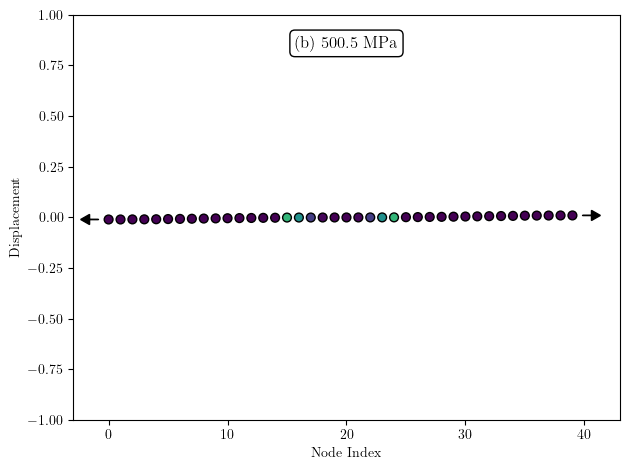

thickness:  1.0


In [3]:
mpl.use('inline')  
#mpl.use("pgf")

# Configure LaTeX rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # Or "xelatex" or "lualatex"
    "text.usetex": True,          # Use LaTeX for all text
    "font.family": "serif",       # Use a serif font
    "pgf.rcfonts": False,})

# Now create your inline plot (no PGF settings will apply)
# Assuming results.damage[-1] is the damage array at the final time step
# (shape should match params.pd_nodes, e.g., (num_nodes,))
# step 1 = [0], step 2 = [10], step 3 = [-1]=disp 
# for optimized step 1 = [0], step 2 = [10], step 3 = [17]

damage_int = results[7][10]
disp_int = results.disp_array[10]
#disp_int = results.disp
#disp_int = results[0]
# damage_final = damage[-1]
damage_final = results[7][10]
x = np.arange(len(damage_final))

fig, ax = plt.subplots()

# Change from ax.plot to ax.scatter for color variation
#sc = ax.scatter(params.pd_nodes, results.disp_array[-1], c=damage_final, cmap="viridis", s=40, edgecolor='k', vmin=0, vmax=1)
# sc = ax.scatter(params.pd_nodes, disp, c=damage_final, cmap="viridis", s=40, edgecolor='k', vmin=0, vmax=1)
sc = ax.scatter(x, disp_int, c=damage_int, cmap="viridis", s=40, edgecolor='k', vmin=0, vmax=1)

ax.set_xlabel("Node Index")
ax.set_ylabel("Displacement")
#ax.set_title("Displacement vs Node Position (Forward Problem)")
ax.set_ylim(-1, 1) 
ax.set_xlim(-3,43)

# Add colorbar
#cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label("Damage")

# Add arrows at the leftmost and rightmost points, pointing outwards
gap = 0.85  # Gap width in x-units
# Left arrow: from leftmost point, pointing left (dx negative)
ax.arrow(x[0] - gap, disp_int[0], -0.75, 0, head_width=0.05, head_length=0.75, fc='k', ec='k', length_includes_head=False)
# Right arrow: from rightmost point, pointing right (dx posiive)
ax.arrow(x[-1] + gap, disp_int[-1], 0.75, 0, head_width=0.05, head_length=0.75, fc='k', ec='k', length_includes_head=False)

# Add a boxed comment in the middle of the plot
ax.text(20, 0.90, "(b) 500.5 MPa", ha='center', va='top', fontsize=12, fontweight='normal',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"), zorder=10)


plt.tight_layout()
plt.savefig("1D_damage_OG_thick_t2_axFix.png", format="png", dpi=300)
plt.show()  # This will display inline in the notebook

print("thickness: ", thickness)

## older code plotting damage evolution without damage coloring

In [ ]:
fig, ax = plt.subplots()
line, = ax.plot([], [], 'k.')
ax.set_xlabel("Node Position")
ax.set_ylabel("Displacement")
ax.set_title("Displacement vs Node Position (Animated)")

# Set axis limits if needed
ax.set_xlim(-5, 5)
# Optionally, set y-limits based on your data
#yMin = displacements[-1].min() - 0.1 * displacements[-1].min()
#yMax = displacements[-1].max() + 0.1 * displacements[-1].max()
#ax.set_ylim(yMin, yMax)
#ax.set_ylim(displacements[-1].min(),displacements[-1].max())
ax.set_ylim(-1.6E5 - 0.1 * 1.6E5, 1.6E5 + 0.1 * 1.6E5)

def init():
    line.set_data([], [])
    return line,

def update(frame):
    disp = displacements[frame]
    line.set_data(params.pd_nodes, disp)
    ax.set_title(f"Displacement, Force={forces_to_apply[frame]:.1e}")
    return line,

ani = animation.FuncAnimation(fig, update, frames=len(displacements), init_func=init, blit=False, repeat=False)

plt.show()
ani.save("displacements.gif", writer="imagemagick", fps=1)

# Optimized Structure Plotting

In [2]:
import matplotlib as mpl

## Saving optimized thicknesses for Plotting

In [84]:
thickness_optimized_L1 = full_thickness

In [ ]:
thickness_optimized_L2_rSeed0 = full_thickness

In [14]:
thickness_optimized_L2_rSeed1 = full_thickness

In [17]:
thickness_optimized_L2_rSeed4 = full_thickness

In [19]:
thickness_optimized_L2_rSeed9 = full_thickness

In [21]:
thickness_optimized_L2_rSeed11 = full_thickness

In [15]:
thick_opt_L2_rSeed0_100steps_LR1 = full_thickness

## Plotting 

python(25269) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(25270) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(25271) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


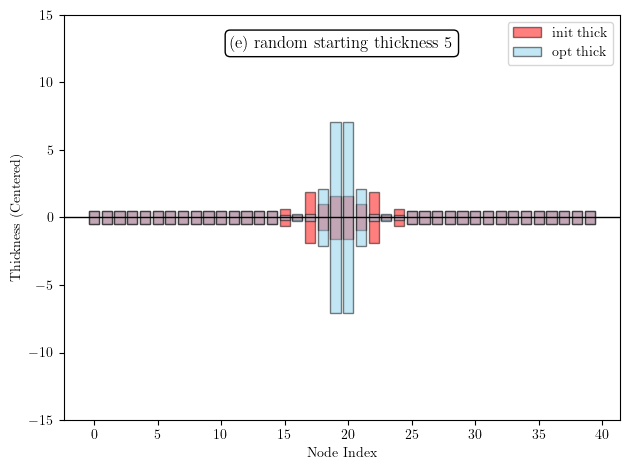

In [46]:
init_thick = jnp.full((num_elems,), 1.0)
x = np.arange(len(full_thickness))

mpl.use('inline')
# Use the PGF backend
#mpl.use("pgf")
plt.clf()


# Configure LaTeX rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # Or "xelatex" or "lualatex"
    "text.usetex": True,          # Use LaTeX for all text
    "font.family": "serif",       # Use a serif font
    "pgf.rcfonts": False,         # Don't override font settingsweights_even_thickness= np.arange(len(full_thickness))
})


plt.bar(x, randomKey0, bottom=-randomKey0/2,
         color="red", edgecolor="k", alpha=0.5, label="init thick")
plt.bar(x, thickness_optimized_L2_rSeed11, bottom=-thickness_optimized_L2_rSeed11/2,
         color="skyblue", edgecolor="k", alpha=0.5, label="opt thick")

ax = plt.gca()  # Get the current axes
ax.text(0.5, 0.95, "(e) random starting thickness 5", ha='center', va='top', fontsize=12, fontweight='normal',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"), 
        transform=ax.transAxes, zorder=10)



plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Node Index")
plt.ylabel("Thickness (Centered)")
#plt.title("Initial vs Optimized Thickness Per Node")
plt.legend()
plt.ylim(-15,15)  # fixed axis range

# Add a boxed comment at the top middle of the plot

plt.tight_layout()
plt.savefig("1D_optimized_thickness_L2_thick11.png", format="png", dpi=300)
plt.show()  # This will display inline in the notebook
#plt.savefig("overlayed_thickness.png", dpi=300, bbox_inches="tight")

# Velocity Wave Propagation Figures

In [42]:
from matplotlib.collections import PolyCollection
import os

plt.clf()

# Configure LaTeX rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # Or "xelatex" or "lualatex"
    "text.usetex": True,          # Use LaTeX for all text
    "font.family": "serif",       # Use a serif font
    "pgf.rcfonts": False,})

forces_to_apply = results[8]
damages = results[7]
displacements = results[9]
velocities = np.abs(results[10])   # keep absolute value

nodes = params.pd_nodes
fixed_disp = displacements[0]
num_nodes = len(nodes)

# ----------------------------------
# HARD-CODED LEFT/RIGHT DIRECTIONS
# ----------------------------------
midpoint = 0.5 * (nodes.min() + nodes.max())

# Arrows on left half → rightward (+1)
# Arrows on right half → leftward (-1)
direction_mask = np.where(nodes < midpoint, 1.0, -1.0)

# ---- FIGURE SETUP ----
fig, ax = plt.subplots()

X = nodes
Y = fixed_disp
U = np.zeros(num_nodes)
V = np.zeros(num_nodes)

# Plot nodes underneath arrows
ax.scatter(X, Y, s=2, color='k', zorder=1)  # nodes below arrows

# Quiver arrows (fully opaque)
Q = ax.quiver(
    X, Y, U, V,
    U,
    cmap="viridis",
    clim=[0, 80],
    angles='xy',
    scale_units='xy',
    scale=0.3,
    width=0.008,
    headwidth=6,
    headlength=8,
    headaxislength=7,
    zorder=10,      # arrows on top
    alpha=1.0       # fully opaque
)

ax.set_xlabel("Node Index")
ax.set_ylabel("Displacement")
ax.set_xlim(nodes.min() - 0.5, nodes.max() + 0.5)
ax.set_ylim(min(fixed_disp) - 0.2, max(fixed_disp) + 0.2)
ax.set_title("Velocity Arrows Propagating Through the Bar")

cbar = fig.colorbar(Q, ax=ax)
cbar.set_label("Velocity Magnitude")

# ----------------------------------
# INIT FUNCTION
# ----------------------------------
def init():
    Q.set_UVC(np.zeros(num_nodes), np.zeros(num_nodes), np.zeros(num_nodes))
    return Q,

# Precompute global max velocity for scaling
global_max_vel = np.max(velocities)
min_arrow_length = 0.05  # minimum arrow length for visibility

# ----------------------------------
# UPDATE FUNCTION
# ----------------------------------
def update(frame):
    vel = velocities[frame]

    # always get velocity magnitude
    if vel.ndim > 1:
        vel_mag = np.linalg.norm(vel, axis=1)
    else:
        vel_mag = np.abs(vel)

    # HARD-CODED ARROW DIRECTIONS
    scaled_U = direction_mask * (vel_mag / (global_max_vel + 1e-12)) * 0.3
    # enforce minimum arrow length
    U = np.where(np.abs(scaled_U) < min_arrow_length,
                 np.sign(scaled_U) * min_arrow_length,
                 scaled_U)

    V = np.zeros(num_nodes)

    Q.set_UVC(U, V, vel_mag)

    ax.set_title(
        f"Velocity Field (Frame {frame}), "
        f"Force={forces_to_apply[frame]:.3e}"
    )

    return Q,

# ----------------------------------
# ANIMATION
# ----------------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(displacements),
    init_func=init,
    blit=False,
    repeat=False
)

plt.tight_layout()

# ----------------------------------
# SAVE SPECIFIC FRAMES
# ----------------------------------
frames_to_save = [1, 7, 13]  # Adjust as needed
os.makedirs("saved_frames", exist_ok=True)
''''
for frame in frames_to_save:
    init()
    update(frame)
    fig.canvas.draw()  # ensure fully rendered
    # Add a boxed comment in the middle of the plot
    if frame == 0:
        ax.text(0, 0.18, "(c) 501.5 MPa", ha='center', va='top', fontsize=12, fontweight='normal',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"), zorder=10)
    if frame == 1:
        ax.text(0, 0.18, "(c) 501.5 MPa", ha='center', va='top', fontsize=12, fontweight='normal',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"), zorder=10)
        
    if frame == 2:
        ax.text(0, 0.18, "(c) 501.5 MPa", ha='center', va='top', fontsize=12, fontweight='normal',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"), zorder=10)

    # **NEW: Remove the title for saved frames**
    ax.set_title("")

    fig.savefig(f"saved_frames/velocity_arrows_frame_{frame}.png",
                dpi=300, bbox_inches='tight')
    print(f"Saved frame {frame} as velocity_arrows_frame_{frame}.png")
'''
plt.show()

# Save animation
ani.save("1D_velocity_arrows_opt_struct.gif", writer="imagemagick", fps=1)

/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_20678/1401338770.py:152: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()
MovieWriter imagemagick unavailable; using Pillow instead.


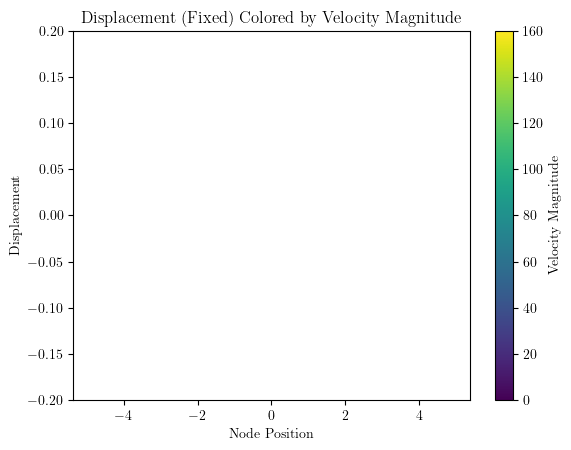

MovieWriter imagemagick unavailable; using Pillow instead.


In [23]:
forces_to_apply = results[8]
damages = results[7]           # unused now
displacements = results[9]
velocities = np.abs(results[10])

nodes = params.pd_nodes  # shape (num_nodes,)
fixed_disp = displacements[0]  # displacement shape remains fixed

fig, ax = plt.subplots()
sc = ax.scatter([], [], c=[], cmap="viridis", vmin=0, vmax=160, s=40)

ax.set_xlabel("Node Position")
ax.set_ylabel("Displacement")
ax.set_title("Displacement (Fixed) Colored by Velocity Magnitude")
ax.set_xlim(nodes.min() - 0.5, nodes.max() + 0.5)
ax.set_ylim(np.min(fixed_disp) - 0.2, np.max(fixed_disp) + 0.2)

# Add colorbar for velocity magnitude
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Velocity Magnitude")

def init():
    coords = np.column_stack((nodes, fixed_disp))
    sc.set_offsets(coords)
    sc.set_array(np.zeros_like(fixed_disp))
    return sc,

def update(frame):
    vel = velocities[frame]

    # Handle both scalar and vector velocities
    if vel.ndim > 1:
        vel_mag = np.linalg.norm(vel, axis=1)
    else:
        vel_mag = np.abs(vel)

    # Displacement remains fixed, only colors update
    coords = np.column_stack((nodes, fixed_disp))
    sc.set_offsets(coords)
    sc.set_array(vel_mag)

    ax.set_title(f"Velocity Field (Frame {frame}), Force={forces_to_apply[frame]:.3e}")
    return sc,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(displacements),
    init_func=init,
    blit=False,
    repeat=False
)

plt.show()
ani.save("fixed_displacement_velocity_colored.gif", writer="imagemagick", fps=1)

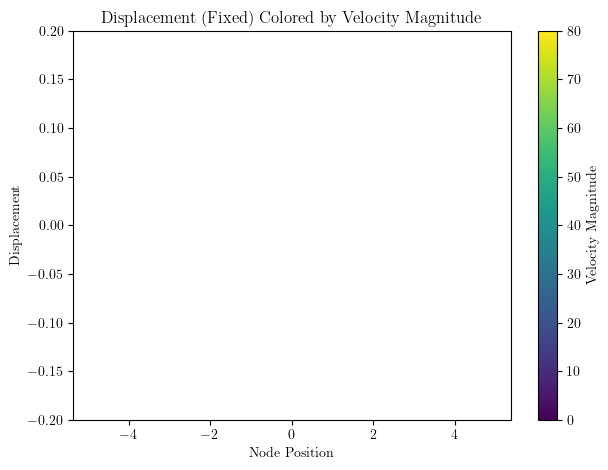

MovieWriter imagemagick unavailable; using Pillow instead.


In [18]:
# Use the PGF backend
#mpl.use("pgf")
mpl.use('inline')
#plt.clf()

# Configure LaTeX rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # Or "xelatex" or "lualatex"
    "text.usetex": True,          # Use LaTeX for all text
    "font.family": "serif",       # Use a serif font
    "pgf.rcfonts": False,         # Don't override font settingsweights_even_thickness= np.arange(len(full_thickness))
})

forces_to_apply = results[8]
damages = results[7]           # unused now
displacements = results[9]
velocities = np.abs(results[10])

nodes = params.pd_nodes  # shape (num_nodes,)
fixed_disp = displacements[0]  # displacement shape remains fixed

fig, ax = plt.subplots()
sc = ax.scatter([], [], c=[], cmap="viridis", vmin=0, vmax=80, s=40)

ax.set_xlabel("Node Position")
ax.set_ylabel("Displacement")
ax.set_title("Displacement (Fixed) Colored by Velocity Magnitude")
ax.set_xlim(nodes.min() - 0.5, nodes.max() + 0.5)
ax.set_ylim(np.min(fixed_disp) - 0.2, np.max(fixed_disp) + 0.2)

# Add colorbar for velocity magnitude
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Velocity Magnitude")

def init():
    coords = np.column_stack((nodes, fixed_disp))
    sc.set_offsets(coords)
    sc.set_array(np.zeros_like(fixed_disp))
    return sc,

def update(frame):
    vel = velocities[frame]

    # Handle both scalar and vector velocities
    if vel.ndim > 1:
        vel_mag = np.linalg.norm(vel, axis=1)
    else:
        vel_mag = np.abs(vel)

    # Displacement remains fixed, only colors update
    coords = np.column_stack((nodes, fixed_disp))
    sc.set_offsets(coords)
    sc.set_array(vel_mag)

    ax.set_title(f"Velocity Field (Frame {frame}), Force={forces_to_apply[frame]:.3e}")
    return sc,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(displacements),
    init_func=init,
    blit=False,
    repeat=False
)


plt.tight_layout()
#plt.savefig("1D_velocity_waves.png", format="png", dpi=300)

plt.show()
ani.save("1D_velocity_waves-2.gif", writer="imagemagick", fps=4)

### with damage color coded in nodes

In [40]:
import matplotlib.animation as animation

# Use the PGF backend
mpl.use("pgf")
#plt.clf()

# Configure LaTeX rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # Or "xelatex" or "lualatex"
    "text.usetex": True,          # Use LaTeX for all text
    "font.family": "serif",       # Use a serif font
    "pgf.rcfonts": False,         # Don't override font settingsweights_even_thickness= np.arange(len(full_thickness))
})

forces_to_apply = results[8]
damages = results[7]
displacements = results[9]

fig, ax = plt.subplots()
# Create an empty scatter instead of a line
sc = ax.scatter([], [], c=[], cmap="viridis", vmin=0, vmax=1, s=40)

ax.set_xlabel("Node Position")
ax.set_ylabel("Displacement")
ax.set_title("Displacement vs Node Position (Animated)")
ax.set_xlim(-5, 5)
ax.set_ylim(-1.0, 1.0)

# add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Damage")

def init():
    sc.set_offsets(np.empty((0, 2)))   # empty coords with correct shape
    sc.set_array(np.array([]))         # empty color array
    return sc,

def update(frame):
    disp = displacements[frame]      # shape (num_nodes,)
    dmg  = damages[frame]            # same shape as disp
    nodes = params.pd_nodes          # shape (num_nodes,)

    # scatter wants Nx2 array for coordinates
    coords = np.column_stack((nodes, disp))
    sc.set_offsets(coords)
    sc.set_array(dmg)  # colors from damage

    ax.set_title(f"Displacement, Force={forces_to_apply[frame]:.3e}")
    return sc,

ani = animation.FuncAnimation(fig, update, frames=len(displacements), init_func=init, blit=False, repeat=False)

plt.show()
ani.save("1D_init_thick_damage_evolving.gif", writer="imagemagick", fps=4)

/var/folders/xw/lq775xyn4hvfd90gbyr0x31r0000gq/T/ipykernel_20678/425040812.py:53: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()
MovieWriter imagemagick unavailable; using Pillow instead.


# Plotting Loss Throughout Optimization

In [47]:
loss_to_plot_200it = jnp.array(loss_to_plot)

index_array__opt_thick_5 = np.arange(len(loss_to_plot_200it))
print("loss_to_plot_200it : ", loss_to_plot_200it)

loss_to_plot_200it :  [102.65854   80.77927   75.107185  56.214317  54.114613  48.49192
  49.87944   47.18542   46.811413  46.18503   45.03714   44.68695
  44.521347  44.23452   39.97287   42.426495  39.726173  39.52881
  18.472183  39.42491   18.177269  38.239952  17.879517  18.18075
  17.71091   17.975264  17.508066  17.084166  17.198635  16.84283 ]


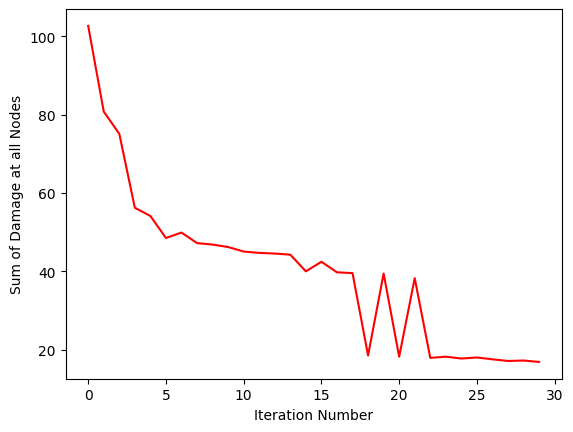

In [ ]:
index_array__opt_thick_5 = np.arange(len(loss_to_plot_200it))

plt.plot(index_array__opt_thick_5,loss_to_plot_200it,c='red',label='init thick 5')
#plt.plot(index_array__opt_thick_5,loss_to_plot_100it,c='blue',label='init thick 5')

#plt.title("Loss vs Iteration Number")
plt.xlabel('Iteration Number')
plt.ylabel('Sum of Damage at all Nodes')
#plt.legend()

#plt.savefig("strainEnergy_variedLossFunction.png", dpi=300, bbox_inches="tight")
plt.show()

# Optimization Code

# Plotting Optimization History (Objective, Max Damage, Material Usage)


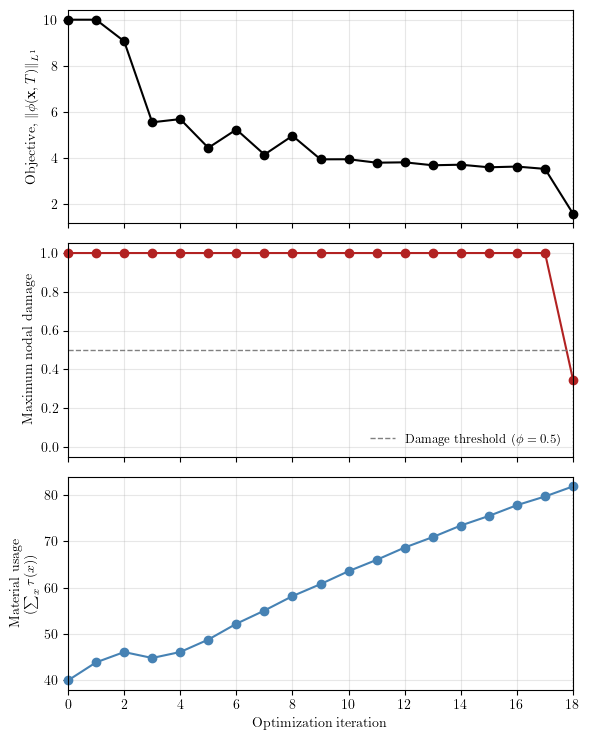

In [3]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl

# Use the PGF backend
mpl.use('inline')
#plt.clf()

# Configure LaTeX rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",  # Or "xelatex" or "lualatex"
    "text.usetex": True,          # Use LaTeX for all text
    "font.family": "serif",       # Use a serif font
    "pgf.rcfonts": False,         # Don't override font settingsweights_even_thickness= np.arange(len(full_thickness))
})

# ----------------------------
# Load the latest checkpoint for this experiment
# ----------------------------
experiment_tag = "1D_bar_damage_L1"  # match whatever experiment_tag you used when running
checkpoint_dir = Path("checkpoints") / experiment_tag

ckpts = list(checkpoint_dir.glob("checkpoint_step_*.pkl"))
if not ckpts:
    raise FileNotFoundError(f"No checkpoints found in {checkpoint_dir}")
latest_ckpt_file = max(ckpts, key=lambda p: int(p.stem.split("_")[-1]))

with open(latest_ckpt_file, "rb") as f:
    ckpt = pickle.load(f)

history = ckpt["history"]
loss = np.array(history["loss_to_plot"], dtype=float)
max_damage = np.array(history["max_damage_to_plot"], dtype=float)
material_usage = np.array(history["material_usage_to_plot"], dtype=float)
iterations = np.arange(len(loss))
early_stop_iter = ckpt["step"]  # iteration at which the loop terminated

damage_threshold = 0.5

# ----------------------------
# Plot: objective, max damage, material usage vs. iteration
# ----------------------------
fig, axes = plt.subplots(3, 1, figsize=(6, 7.5), sharex=True)

axes[0].plot(iterations, loss, marker="o", color="black", linewidth=1.5, clip_on=False)
axes[0].set_ylabel(r"Objective, $\|\phi(\mathbf{x}, T)\|_{L^1}$")

axes[1].plot(iterations, max_damage, marker="o", color="firebrick", linewidth=1.5, clip_on=False)
axes[1].axhline(damage_threshold, color="gray", linestyle="--", linewidth=1.0,
                 label=r"Damage threshold ($\phi = 0.5$)")
axes[1].set_ylabel("Maximum nodal damage")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc="lower right", frameon=False, fontsize=9)

axes[2].plot(iterations, material_usage, marker="o", color="steelblue", linewidth=1.5, clip_on=False)
axes[2].set_ylabel("Material usage\n" + r"($\sum_x \tau(x)$)")
axes[2].set_xlabel("Optimization iteration")

# Mark the early-stopping iteration across all panels
for ax in axes:
    ax.axvline(early_stop_iter, color="black", linestyle=":", linewidth=1.0, alpha=0.6)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, max(iterations))

import os
os.makedirs("PaperReviewFigures", exist_ok=True)


plt.tight_layout()
plt.savefig("PaperReviewFigures/1D_L1_damage_optimization_history.png", dpi=300, bbox_inches="tight")
plt.show()


In [3]:
# # Now using Optax to maximize
# random array of thickness values for initial thickness 
#key = jax.random.PRNGKey(0) 
#shape = (params.num_nodes,)  # Example shape
#param = jax.random.uniform(key, shape=shape, minval=0.5, maxval=1.5)

# scalar param and starting array of all 1's, optimizing thickness at every node
#param = jnp.array([1.0])
param = jnp.full((num_elems,), 1.0)

# optimizing only half of bar, such that thickness is symmetric
num_nodes = params.num_nodes
mid_index = num_nodes // 2  # midpoint of bar

no_damage_region_left = params.no_damage_region_left
no_damage_region_right = params.no_damage_region_right

middle_region = jnp.arange(jnp.max(no_damage_region_left) + 1, jnp.min(no_damage_region_right))
print("middle region: ", middle_region)

# region to optimize: left side *outside* no_damage_region
optimizable_indices = jnp.arange(0, mid_index)
optimizable_indices = optimizable_indices[~jnp.isin(optimizable_indices, no_damage_region_left)]

#print("no_damage_region_left: ", no_damage_region_left)
#print("no_damage_region_right: ", no_damage_region_right)
#print("optimizable_indices: ", optimizable_indices)

param = jnp.ones((optimizable_indices.size,)) 
#key = jax.random.PRNGKey(11)
#shape = (optimizable_indices.size,)  # Example shape
#param = jax.random.uniform(key, shape=shape, minval=0.3, maxval=5.0)
print("initial param: ", param)

# ----------------------------
# Checkpointing setup
# ----------------------------
# Change experiment_tag whenever the loss norm, random seed, or other setup in this
# cell changes, so that resuming doesn't accidentally load a checkpoint from a
# different experiment.
import pickle
from pathlib import Path

experiment_tag = "1D_bar_damage_L1"
checkpoint_dir = Path("checkpoints") / experiment_tag
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_every = 5  # save a checkpoint every N optimization steps

def _checkpoint_path(step):
	return checkpoint_dir / f"checkpoint_step_{step}.pkl"

def _latest_checkpoint():
	ckpts = list(checkpoint_dir.glob("checkpoint_step_*.pkl"))
	if not ckpts:
		return None
	return max(ckpts, key=lambda p: int(p.stem.split("_")[-1]))

def save_checkpoint(step, param, opt_state, history):
	with open(_checkpoint_path(step), "wb") as f:
		pickle.dump({"step": step, "param": param, "opt_state": opt_state, "history": history}, f)
	print(f"Saved checkpoint at step {step} -> {_checkpoint_path(step)}")

loss_to_plot = []
damage_to_plot = []
max_damage_to_plot = []
material_usage_to_plot = []
strain_energy_to_plot =[]
damage = []

# when use strain energy density as loss, use smaller
#learning_rate = 1E-1

learning_rate = 1.0
#learning_rate = 0.1
num_steps = 20
thickness_min = 1.0E-2
thickness_max = 1.0E2

## Define gradient bounds
lower = 1E-2
upper = 20

#max_time = 1.0E-02
max_time = 5.0E-03
#max_time = 1.0E-03
#max_time = 1.0E-01

'''
# setting learning rate schedule
schedule = optax.piecewise_constant_schedule(
    init_value=1.0,  # Starting LR at 1.0
    boundaries_and_scales={
        20: 0.1,   # At step 20 , multiply by 0.1 (change to 0.1), and stay at 0.1 thereafter
    }
)


# Optax optimizer
optimizer = optax.adam(schedule)
opt_state = optimizer.init(param)
'''

# Optax optimizer
optimizer = optax.adam(learning_rate=1.0)
opt_state = optimizer.init(param)

# Resume from the latest checkpoint, if one exists for this experiment_tag
start_step = 0
_ckpt_file = _latest_checkpoint()
if _ckpt_file is not None:
	with open(_ckpt_file, "rb") as f:
		_ckpt = pickle.load(f)
	param = _ckpt["param"]
	opt_state = _ckpt["opt_state"]
	loss_to_plot = _ckpt["history"]["loss_to_plot"]
	damage_to_plot = _ckpt["history"]["damage_to_plot"]
	max_damage_to_plot = _ckpt["history"]["max_damage_to_plot"]
	material_usage_to_plot = _ckpt["history"]["material_usage_to_plot"]
	strain_energy_to_plot = _ckpt["history"]["strain_energy_to_plot"]
	start_step = _ckpt["step"] + 1
	print(f"Resuming '{experiment_tag}' from checkpoint at step {_ckpt['step']} ({_ckpt_file})")
else:
	print(f"No checkpoint found for '{experiment_tag}', starting from scratch.")

# Optimization loop
damage_threshold = 0.5

# Loss function (already defined as 'loss')
#loss_and_grad = jax.value_and_grad(loss, argnums=2)
loss_and_grad = jax.value_and_grad(loss, argnums=2, has_aux=True)

# Clamp function
def clamp_params(grads):
	lower = 1E-05
	upper = 1.0E10
	#jax.debug.print("entering clamp_params: {t}", t=grads)
	grads = jax.tree_util.tree_map(lambda x: jnp.clip(jnp.abs(x), lower, upper), grads)
	#jax.debug.print("grad after clamping: {t}", t=grads)
	return grads

def make_symmetric_thickness(left_params):
    """Return full symmetric thickness array of shape (num_nodes,)."""
    left_fixed_thickness = 3.0
    right_fixed_thickness = 3.0

    # Mirror optimized section
    mirrored = left_params[::-1]
    middle_full = jnp.concatenate([left_params, mirrored])

    # Construct full bar thickness
    full_thickness = jnp.ones((num_nodes,))  # shape (num_nodes,)

    # Insert middle region
    full_thickness = full_thickness.at[middle_region].set(middle_full)

    # Fix the outer ends
    full_thickness = full_thickness.at[no_damage_region_left].set(left_fixed_thickness)
    full_thickness = full_thickness.at[no_damage_region_right].set(right_fixed_thickness)

    return full_thickness

initial_full_thickness = make_symmetric_thickness(param)

# Cache the baseline forward solve (expensive) so reopening the notebook doesn't
# force a recompute; stored alongside the optimization checkpoints for this experiment.
baseline_cache_file = checkpoint_dir / "baseline_damage.pkl"
if baseline_cache_file.exists():
	with open(baseline_cache_file, "rb") as f:
		baseline_damage = pickle.load(f)
	print("Loaded cached baseline damage from disk.")
else:
	baseline_output = _solve(params, state, thickness=initial_full_thickness, forces_array=forces_array, allow_damage=allow_damage, max_time=max_time)
	baseline_damage = baseline_output.damage[-1]
	with open(baseline_cache_file, "wb") as f:
		pickle.dump(baseline_damage, f)
	print("Computed baseline damage and cached it to disk.")

print("initial damage, full vector: ", baseline_damage)
print("Baseline damage (initial thickness): ", baseline_damage.sum())

# Optimization loop
for step in range(start_step, num_steps):
	def true_fn(thickness):
		jax.debug.print("thickness is all finite.")
		return thickness

	def false_fn(thickness):
		jax.debug.print("Non-finite thickness detected: {t}", t=thickness)
		return thickness

	full_thickness = make_symmetric_thickness(param)
	assert jnp.all(jnp.isfinite(param)), "Initial thickness contains NaNs!"

	# enforce fixed region if needed
	full_thickness = full_thickness.at[no_damage_region_left].set(1.0)
	full_thickness = full_thickness.at[no_damage_region_right].set(1.0)

	# Compute loss and gradients (grads wrt half param)
	(loss_val, (strain_energy, damage)), grads_full = loss_and_grad(
		params, state, full_thickness, 
		forces_array=forces_array, allow_damage=allow_damage, max_time=max_time
	)

	# Extract grads only for half region
	grads = grads_full[optimizable_indices]

	updates, opt_state = optimizer.update(grads, opt_state, param)
	param = optax.apply_updates(param, updates)
	param = jnp.clip(jnp.abs(param), 0.3, None)

	loss_to_plot.append(loss_val)
	strain_energy_to_plot.append(strain_energy)
	damage_to_plot.append(damage)
	max_damage_to_plot.append(damage.max())
	material_usage_to_plot.append(full_thickness.sum())

	jax.debug.print("Step {s}, loss={l}, thickness={t}, gradients={g}, total_damage={d}", d=damage.sum(),
					s=step, l=loss_val, t=full_thickness, g=grads)
	print("damage in optimization loop: ", damage_to_plot[-1].sum())

	damage_threshold = 0.5

	history = {
		"loss_to_plot": loss_to_plot,
		"damage_to_plot": damage_to_plot,
		"max_damage_to_plot": max_damage_to_plot,
		"material_usage_to_plot": material_usage_to_plot,
		"strain_energy_to_plot": strain_energy_to_plot,
	}

	# Periodic checkpoint keyed by cumulative step count
	if (step + 1) % checkpoint_every == 0:
		save_checkpoint(step, param, opt_state, history)

	# Early stopping condition: Check if ALL node damages are below the threshold
	if jnp.all(damage < damage_threshold):
		print(f"Early stopping at step {step}: All damages are below {damage_threshold}.")
		jax.debug.print("Early stopping: All damages below threshold.")
		save_checkpoint(step, param, opt_state, history)
		break  # Exit the loop


middle region:  [15 16 17 18 19 20 21 22 23 24]
initial param:  [1. 1. 1. 1. 1.]
No checkpoint found for '1D_bar_damage_L1', starting from scratch.
Computed baseline damage and cached it to disk.
initial damage, full vector:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Baseline damage (initial thickness):  10.0
inf_state after run: [[1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 

# Visualizing Init Thickness for Optimzing L2 Norm

In [41]:
param = jnp.full((num_elems,), 0.5)

# optimizing only half of bar, such that thickness is symmetric
num_nodes = params.num_nodes
mid_index = num_nodes // 2  # midpoint of bar

no_damage_region_left = params.no_damage_region_left
no_damage_region_right = params.no_damage_region_right

middle_region = jnp.arange(jnp.max(no_damage_region_left) + 1, jnp.min(no_damage_region_right))

# region to optimize: left side *outside* no_damage_region
optimizable_indices = jnp.arange(0, mid_index)
optimizable_indices = optimizable_indices[~jnp.isin(optimizable_indices, no_damage_region_left)]

#param = jnp.ones((optimizable_indices.size,)) 
key = jax.random.PRNGKey(3) 
shape = (optimizable_indices.size,)  # Example shape
param = jax.random.uniform(key, shape=shape, minval=0.3, maxval=5.0)
print("initial param: ", param)

initial param:  [0.6480471 4.709278  3.350098  4.8854184 1.6083754]


In [42]:
param = jnp.full((num_elems,), 0.5)

# optimizing only half of bar, such that thickness is symmetric
num_nodes = params.num_nodes
mid_index = num_nodes // 2  # midpoint of bar

no_damage_region_left = params.no_damage_region_left
no_damage_region_right = params.no_damage_region_right

middle_region = jnp.arange(jnp.max(no_damage_region_left) + 1, jnp.min(no_damage_region_right))
#print("middle region: ", middle_region)

# region to optimize: left side *outside* no_damage_region
optimizable_indices = jnp.arange(0, mid_index)
optimizable_indices = optimizable_indices[~jnp.isin(optimizable_indices, no_damage_region_left)]

#print("no_damage_region_left: ", no_damage_region_left)
#print("no_damage_region_right: ", no_damage_region_right)
#print("optimizable_indices: ", optimizable_indices)

#param = jnp.ones((optimizable_indices.size,)) 
key = jax.random.PRNGKey(0) 
shape = (optimizable_indices.size,)  # Example shape
param = jax.random.uniform(key, shape=shape, minval=0.3, maxval=5.0)
print("initial param: ", param)


initial param:  [4.7540345 4.8993254 1.8617699 2.5027416 2.9784768]


initial param:  [1.2859788  0.38810742 3.7189622  1.9219164  3.1662328 ]


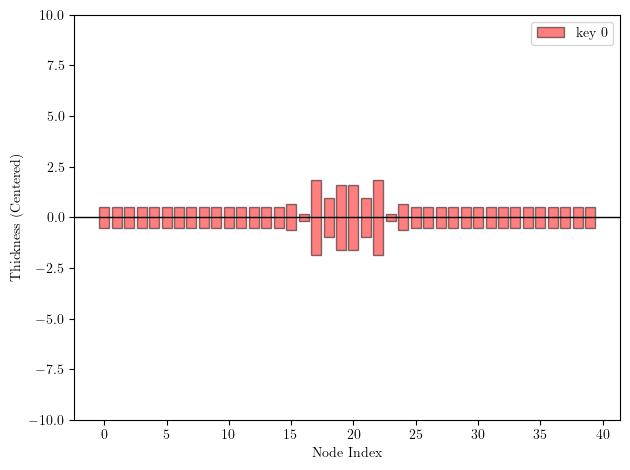

In [45]:
def create_full_thickness(index):
    """
    Creates the full symmetric thickness array from the optimized param array.
    
    Args:
        param: The optimized thickness parameters for the left half (shape: (optimizable_indices.size,))
    
    Returns:
        full_thickness: The full thickness array for all nodes (shape: (num_nodes,))
    """
    #param = jnp.ones((optimizable_indices.size,)) 
    key = jax.random.PRNGKey(index) 
    shape = (optimizable_indices.size,)  # Example shape
    param = jax.random.uniform(key, shape=shape, minval=0.3, maxval=5.0)
    print("initial param: ", param)
        
    full_thickness = make_symmetric_thickness(param)
    assert jnp.all(jnp.isfinite(param)), "Initial thickness contains NaNs!"
    
    # Enforce fixed thickness in no-damage regions
    full_thickness = full_thickness.at[no_damage_region_left].set(1.0)
    full_thickness = full_thickness.at[no_damage_region_right].set(1.0)
    
    return full_thickness


param = jnp.full((num_elems,), 0.5)

# optimizing only half of bar, such that thickness is symmetric
num_nodes = params.num_nodes
mid_index = num_nodes // 2  # midpoint of bar

no_damage_region_left = params.no_damage_region_left
no_damage_region_right = params.no_damage_region_right

middle_region = jnp.arange(jnp.max(no_damage_region_left) + 1, jnp.min(no_damage_region_right))
#print("middle region: ", middle_region)

# region to optimize: left side *outside* no_damage_region
optimizable_indices = jnp.arange(0, mid_index)
optimizable_indices = optimizable_indices[~jnp.isin(optimizable_indices, no_damage_region_left)]



randomKey0 = create_full_thickness(11)
x = np.arange(len(randomKey0))


'''
def true_fn(thickness):
    jax.debug.print("thickness is all finite.")
    return thickness

def false_fn(thickness):
    jax.debug.print("Non-finite thickness detected: {t}", t=thickness)
    return thickness

full_thickness = make_symmetric_thickness(param)
assert jnp.all(jnp.isfinite(param)), "Initial thickness contains NaNs!"

# enforce fixed region if needed
full_thickness = full_thickness.at[no_damage_region_left].set(1.0)
full_thickness = full_thickness.at[no_damage_region_right].set(1.0)
'''
plt.clf()

plt.bar(x, randomKey0, bottom=-randomKey0/2,
         color="red", edgecolor="k", alpha=0.5, label="key 0")

#plt.bar(x, randomKey1, bottom=-randomKey1/2,
         #color="pink", edgecolor="k", alpha=0.5, label="key 1")

#plt.bar(x, randomKey2, bottom=-randomKey2/2,
         #color="lightblue", edgecolor="k", alpha=0.5, label="key 2")

#plt.bar(x, randomKey3, bottom=-randomKey3/2,
         #color="darkblue", edgecolor="k", alpha=0.5, label="key 3")
         
#plt.bar(x, randomKey4, bottom=-randomKey4/2,
         #color="blue", edgecolor="k", alpha=0.5, label="key 4")

plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Node Index")
plt.ylabel("Thickness (Centered)")
#plt.title("Initial vs Optimized Thickness Per Node")
plt.legend()
plt.ylim(-10,10)  # fixed axis range

# Add a boxed comment at the top middle of the plot

plt.tight_layout()
#plt.savefig("1D_optimized_thickness_L2_horiz_label.png", format="png", dpi=300)
plt.show()  # This will display inline in the notebook